In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_validate,GridSearchCV


In [24]:
data_path="D:/maktab/145/first mini project/creditcard.csv"
fraud_data = pd.read_csv(data_path)
display(fraud_data)
display(fraud_data.info())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

In [25]:
print("--------------------- Checking duplicated --------------------")
print("dataframe shape before deleting duplicatations : ",fraud_data.shape)
fraud=fraud_data.drop_duplicates()
print("dataframe shape after deleting duplicatations : ",fraud.shape)
print("---------------- Checking Null values ------------------")
print("Number of Null values is : ",fraud.isna().sum())
print("-------------------- Checking data quality ----------------------")
negative_time_count = (fraud_data['Time'] < 0).sum()
negative_amount_count = (fraud_data['Amount'] < 0).sum()
print(f"Number of negative Time values: {negative_time_count}")
print(f"Number of negative Amount values: {negative_amount_count}")
if negative_time_count == 0 and negative_amount_count == 0:
    print("Data Quality Passed: No negative values found in Time or Amount.")
else:
    print("Data Quality Alert: Negative values detected!")



--------------------- Checking duplicated --------------------
dataframe shape before deleting duplicatations :  (284807, 31)
dataframe shape after deleting duplicatations :  (283726, 31)
---------------- Checking Null values ------------------
Number of Null values is :  Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
-------------------- Checking data quality ----------------------
Number of negative Time values: 0
Number of negative Amount values: 0
Data Quality Passed: No negative values found in Time or Amount.


In [26]:
print("---------------- Checking data Imbalance ---------------")
class_True=(fraud["Class"]==0).sum()
print(class_True)
class_False=(fraud["Class"]==1).sum()
print(class_False)

---------------- Checking data Imbalance ---------------
283253
473


In [27]:
x_fraud=fraud.drop(columns=["Class"])
y_fraud=fraud["Class"]
x_train,x_test,y_train,y_test=train_test_split(x_fraud,y_fraud,test_size=0.2,random_state=42,stratify=y_fraud)

# Logestic Model

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746



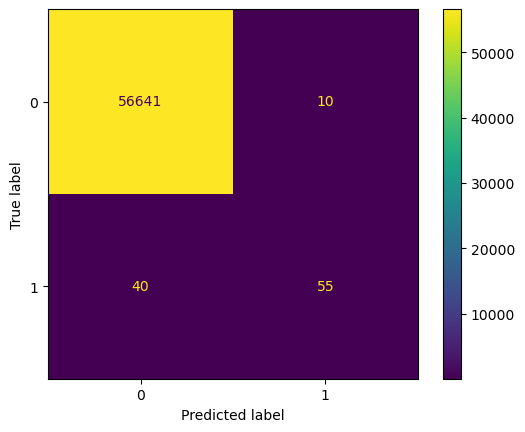

In [28]:
scaler_logestic=StandardScaler()
x_fraud_logestic_train=scaler_logestic.fit_transform(x_train)
x_fraud_logestic_test=scaler_logestic.transform(x_test)
logestic_model=LogisticRegression()
logestic_model.fit(x_fraud_logestic_train,y_train)

logestic_prediction_train=logestic_model.predict(x_fraud_logestic_train)
logestic_prediction_test=logestic_model.predict(x_fraud_logestic_test)
report_logestic=classification_report(y_test,logestic_prediction_test)
print(report_logestic)
cm_logestic=confusion_matrix(y_test,logestic_prediction_test)
cm_logestic_display=ConfusionMatrixDisplay(cm_logestic)
cm_logestic_display.plot()
plt.show()

In [29]:
logestic_pipeline=make_pipeline(
    StandardScaler(),
    LogisticRegression()
)
evalutaion_metrics=["accuracy","recall","precision","f1"]
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_result=cross_validate(
    logestic_pipeline,
    x_train,
    y_train,
    scoring=evalutaion_metrics,
    cv=cv,
)
for metric in evalutaion_metrics:
    mean_score = cv_result[f"test_{metric}"].mean()
    print(f"Mean {metric.capitalize()}: {mean_score:.4f} ")



Mean Accuracy: 0.9992 
Mean Recall: 0.6056 
Mean Precision: 0.8633 
Mean F1: 0.7096 


### Threshold impact

In [30]:
y_probs = logestic_model.predict_proba(x_fraud_logestic_test)[:, 1]
for th in [0.3, 0.5, 0.7]:
    y_pred_th = (y_probs >= th).astype(int)
    print(f"--- Threshold: {th} ---")
    print(classification_report(y_test, y_pred_th))

--- Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.64      0.73        95

    accuracy                           1.00     56746
   macro avg       0.92      0.82      0.86     56746
weighted avg       1.00      1.00      1.00     56746

--- Threshold: 0.5 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746

--- Threshold: 0.7 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.52      0.64        95

    accuracy                           1.00     56746
   macro avg       0.92      0.76      0.82     56746
weigh

In [31]:
print("")
print("=================== CV with GridSearch(Logestic) ======================")
print("")

logestic_pipeline_grid = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

logestic_param_grid = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100]
}

logestic_grid_search = GridSearchCV(
    estimator=logestic_pipeline_grid,
    param_grid=logestic_param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

logestic_grid_search.fit(x_train, y_train)

print("Best C:", logestic_grid_search.best_params_)
print("Best CV F1 score:", logestic_grid_search.best_score_)


=================== CV with GridSearch(Logestic) ======================

Best C: {'logisticregression__C': 1}
Best CV F1 score: 0.7096443502194244


# KNN Model

#### Without Scalling

KNN with k = 1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.42      0.15      0.22        95

    accuracy                           1.00     56746
   macro avg       0.71      0.57      0.61     56746
weighted avg       1.00      1.00      1.00     56746



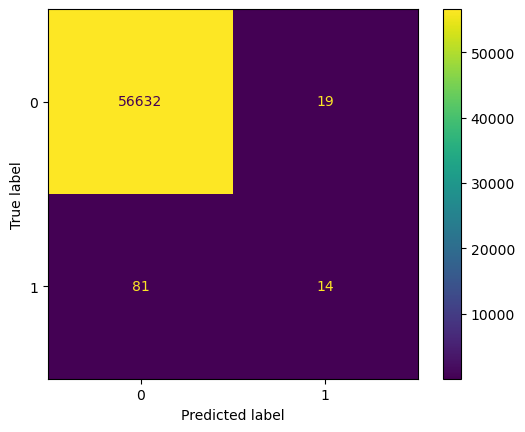

KNN with k = 5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       1.00      0.02      0.04        95

    accuracy                           1.00     56746
   macro avg       1.00      0.51      0.52     56746
weighted avg       1.00      1.00      1.00     56746



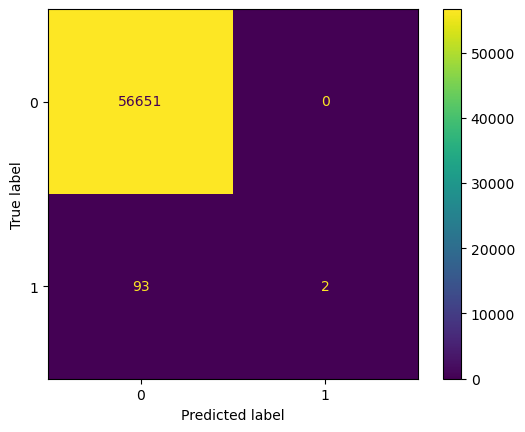

KNN with k = 20
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.00      0.00      0.00        95

    accuracy                           1.00     56746
   macro avg       0.50      0.50      0.50     56746
weighted avg       1.00      1.00      1.00     56746



c:\Users\Elahe\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Elahe\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Elahe\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


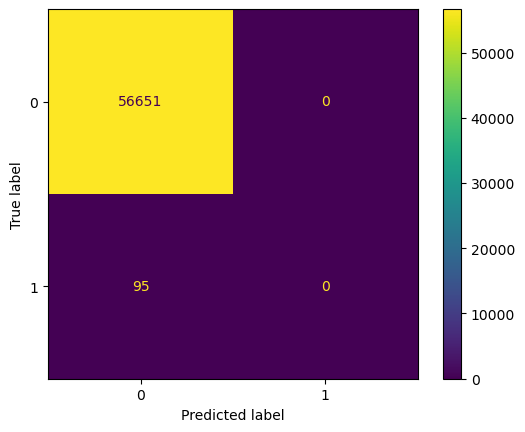

In [32]:
k_neighbors=[1,5,20]
results=[]
for i in range(0,3):
    knn_model=KNeighborsClassifier(n_neighbors=k_neighbors[i])
    knn_model.fit(x_train,y_train)
    prediction_knn=knn_model.predict(x_test)
    print(f"KNN with k = {k_neighbors[i]}")
    print(classification_report(y_test,prediction_knn))
    cm_knn=confusion_matrix(y_test,prediction_knn)
    cm_knn_display=ConfusionMatrixDisplay(cm_knn)
    cm_knn_display.plot()
    plt.show()

    results.append({
        'K Value': k_neighbors[i],
        'Scaling': 'Without Scaling',
        'Precision': round(precision_score(y_test, prediction_knn, zero_division=0), 4),
        'Recall': round(recall_score(y_test,prediction_knn, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, prediction_knn, zero_division=0), 4)
    })

#### Scaled_Knn

KNN with k = 1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.83      0.72      0.77        95

    accuracy                           1.00     56746
   macro avg       0.91      0.86      0.88     56746
weighted avg       1.00      1.00      1.00     56746



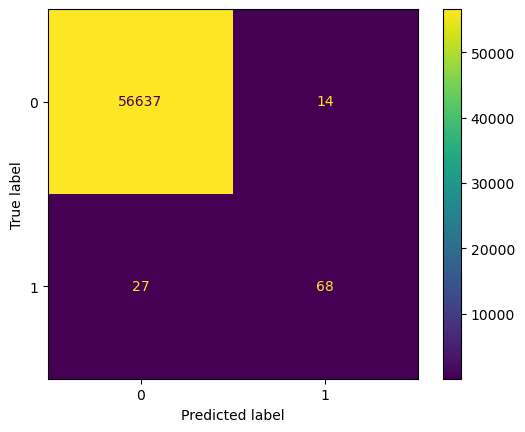

KNN with k = 5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.68      0.80        95

    accuracy                           1.00     56746
   macro avg       0.98      0.84      0.90     56746
weighted avg       1.00      1.00      1.00     56746



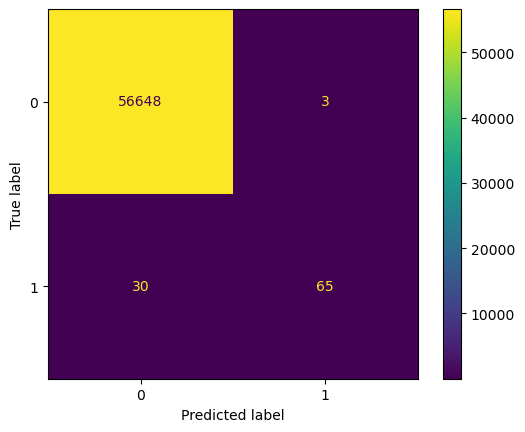

KNN with k = 20
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.68      0.78        95

    accuracy                           1.00     56746
   macro avg       0.96      0.84      0.89     56746
weighted avg       1.00      1.00      1.00     56746



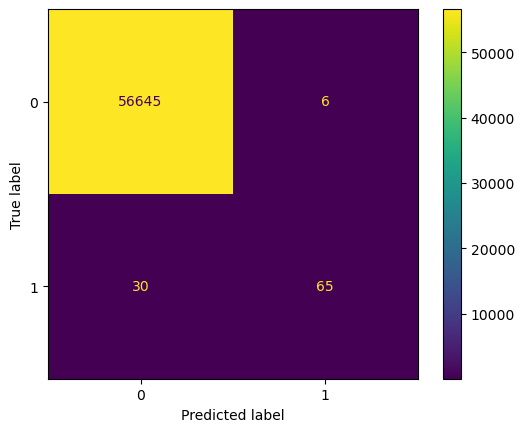


===================Scaled vs without Scaled KNN====================



,K Value,Scaling,Precision,Recall,F1-Score
0,1,Without Scaling,0.4242,0.1474,0.2188
1,5,Without Scaling,1.0000,0.0211,0.0412
2,20,Without Scaling,0.0000,0.0000,0.0000
3,1,With Scaling,0.8293,0.7158,0.7684
4,5,With Scaling,0.9559,0.6842,0.7975
5,20,With Scaling,0.9155,0.6842,0.7831


In [33]:
knn_scaled=StandardScaler()
x_train_knn_scaled=knn_scaled.fit_transform(x_train)
x_test_knn_scaled=knn_scaled.transform(x_test)
k_neighbors=[1,5,20]
for i in range(0,3):
    knn_model=KNeighborsClassifier(n_neighbors=k_neighbors[i])
    knn_model.fit(x_train_knn_scaled,y_train)
    prediction_knn_scaled=knn_model.predict(x_test_knn_scaled)
    print(f"KNN with k = {k_neighbors[i]}")
    print(classification_report(y_test,prediction_knn_scaled))
    cm_knn_scaled=confusion_matrix(y_test,prediction_knn_scaled)
    cm_knn_display_scaled=ConfusionMatrixDisplay(cm_knn_scaled)
    cm_knn_display_scaled.plot()
    plt.show()


    results.append({
        'K Value': k_neighbors[i],
        'Scaling': 'With Scaling',
        'Precision': round(precision_score(y_test, prediction_knn_scaled, zero_division=0), 4),
        'Recall': round(recall_score(y_test, prediction_knn_scaled, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, prediction_knn_scaled, zero_division=0), 4)
    })

print("")
print("===================Scaled vs without Scaled KNN====================")
print("")
df_results = pd.DataFrame(results)
display(df_results)

In [34]:
knn_pipeline=make_pipeline(
    StandardScaler(),
    KNeighborsClassifier()
)
evalutaion_metrics=["accuracy","recall","precision","f1"]
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_result=cross_validate(
    knn_pipeline,
    x_train,
    y_train,
    scoring=evalutaion_metrics,
    cv=cv,
)
for metric in evalutaion_metrics:
    mean_score = cv_result[f"test_{metric}"].mean()
    print(f"Mean {metric.capitalize()}: {mean_score:.4f} ")




Mean Accuracy: 0.9995 
Mean Recall: 0.7646 
Mean Precision: 0.9157 
Mean F1: 0.8318 


In [35]:
print("")
print("=================== CV with GridSearch (KNN)======================")
print("")

knn_pipeline=make_pipeline(
    StandardScaler(),
    KNeighborsClassifier()
)
knn_param_grid = {"kneighborsclassifier__n_neighbors": [1, 3, 5, 7, 11, 15,19]}
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
knn_grid=GridSearchCV(
    knn_pipeline,
    param_grid=knn_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
knn_grid.fit(x_train, y_train)

print("Best k:", knn_grid.best_params_)
print("Best CV f1 score:", knn_grid.best_score_)


best_knn_model = knn_grid.best_estimator_
knn_grid_prediction = best_knn_model.predict(x_test)
print(classification_report(y_test, knn_grid_prediction))


=================== CV with GridSearch (KNN)======================

Best k: {'kneighborsclassifier__n_neighbors': 3}
Best CV f1 score: 0.848143732205172
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.72      0.81        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



# Desicion Tree model

 max depth is None
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.70      0.69      0.70        95

    accuracy                           1.00     56746
   macro avg       0.85      0.85      0.85     56746
weighted avg       1.00      1.00      1.00     56746



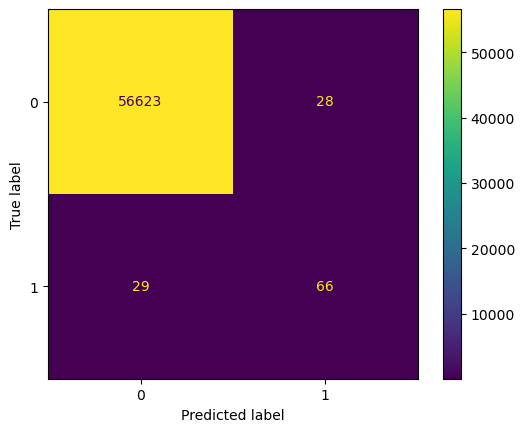

 max depth is 2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.69      0.76        95

    accuracy                           1.00     56746
   macro avg       0.92      0.85      0.88     56746
weighted avg       1.00      1.00      1.00     56746



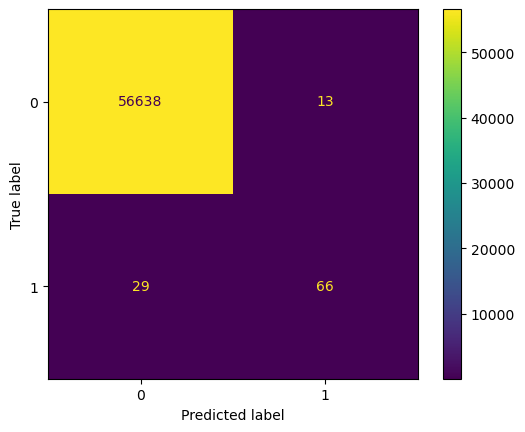

 max depth is 5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.69      0.78        95

    accuracy                           1.00     56746
   macro avg       0.94      0.85      0.89     56746
weighted avg       1.00      1.00      1.00     56746



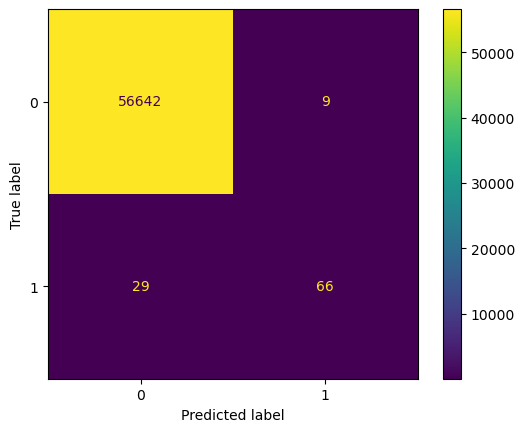

 max depth is 10
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.68      0.77        95

    accuracy                           1.00     56746
   macro avg       0.94      0.84      0.88     56746
weighted avg       1.00      1.00      1.00     56746



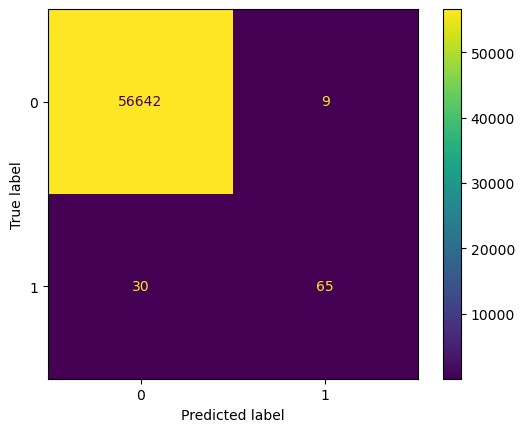

In [36]:
depth = [None,2,5,10]
for i in range(4):
    print(f" max depth is {depth[i]}")
    desicion_model=DecisionTreeClassifier(max_depth=depth[i])
    desicion_model.fit(x_train,y_train)
    decision_prediction=desicion_model.predict(x_test)

    print(classification_report(y_test,decision_prediction))
    cm_decision_prediction=confusion_matrix(y_test,decision_prediction)
    cm_decision_prediction=ConfusionMatrixDisplay(confusion_matrix=cm_decision_prediction)
    cm_decision_prediction.plot()
    plt.show()


### Cross validation

In [37]:
desicion_pipeline=make_pipeline(
    DecisionTreeClassifier()
)
evalutaion_metrics=["accuracy","recall","precision","f1"]
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_result=cross_validate(
    desicion_pipeline,
    x_train,
    y_train,
    scoring=evalutaion_metrics,
    cv=cv,
)
for metric in evalutaion_metrics:
    mean_score = cv_result[f"test_{metric}"].mean()
    print(f"Mean {metric.capitalize()}: {mean_score:.4f} ")




Mean Accuracy: 0.9991 
Mean Recall: 0.7511 
Mean Precision: 0.7385 
Mean F1: 0.7429 


In [38]:
print("")
print("=================== CV with GridSearch (Desicion Tree) ======================")
print("")

desicion_pipeline=make_pipeline(
    DecisionTreeClassifier()
)
tree_param_grid = {
    'decisiontreeclassifier__max_depth': [2, 3, 5, 7, 10, None]
}

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
tree_grid_search=GridSearchCV(
    desicion_pipeline,
    param_grid=tree_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
tree_grid_search.fit(x_train, y_train)

print("Best max_depth:", tree_grid_search.best_params_)
print("Best CV F1 score:", tree_grid_search.best_score_)

best_tree_model = tree_grid_search.best_estimator_
tree_grid_prediction = best_tree_model.predict(x_test)
print(classification_report(y_test, tree_grid_prediction))


=================== CV with GridSearch (Desicion Tree) ======================

Best max_depth: {'decisiontreeclassifier__max_depth': 5}
Best CV F1 score: 0.8310723543564732
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.71      0.78        95

    accuracy                           1.00     56746
   macro avg       0.94      0.85      0.89     56746
weighted avg       1.00      1.00      1.00     56746

